In [2]:
import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, retrieval_success

rng = np.random.default_rng(0)

n_neurons = 2000
sparsity = 0.1

print(f"N_neurons = {n_neurons}, sparsity p = {sparsity}")

N_neurons = 2000, sparsity p = 0.1


In [3]:
def build_network_with_memories(n_neurons, sparsity, n_old, rng, sequential=True):
    """Construct a network with n_old old memories, then fear and extinction.

    Returns
    -------
    net : HopfieldNetwork
    old_patterns : list[np.ndarray]
    fear_pattern : np.ndarray
    ext_pattern : np.ndarray
    storage_mode : str
        'sequential' or 'parallel'
    """
    net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)

    # generate all patterns first so sequential vs parallel see same set
    all_patterns = [generate_sparse_pattern(n_neurons, sparsity, rng=rng) for _ in range(n_old + 2)]
    old_patterns = all_patterns[:n_old]
    fear_pattern = all_patterns[n_old]
    ext_pattern = all_patterns[n_old + 1]

    if sequential:
        # store old, then fear, then extinction sequentially
        for p in old_patterns:
            net.store_pattern_sequential(p)
        net.store_pattern_sequential(fear_pattern)
        net.store_pattern_sequential(ext_pattern)
        storage_mode = "sequential"
    else:
        # parallel: all-at-once
        net.store_patterns(old_patterns + [fear_pattern, ext_pattern])
        storage_mode = "parallel"

    return net, old_patterns, fear_pattern, ext_pattern, storage_mode


def retrieve_overlap(net, pattern):
    final_state, traj, energies = net.run(
        initial_state=pattern,
        external_input=None,
        beta=1.0,
        theta=0.0,
        max_steps=50,
        asynchronous=False,
    )
    return pattern_overlap(final_state, pattern)

In [4]:
# Sweep number of old memories and examine retrieval quality

n_old_list = np.arange(0, 201, 20)  # 0,20,...,200 old memories

results_seq = {"n_old": [], "fear": [], "ext": [], "old_mean": [], "old_min": []}
results_par = {"n_old": [], "fear": [], "ext": [], "old_mean": [], "old_min": []}

for n_old in n_old_list:
    # use separate RNGs so sequential/parallel each see their own random draw,
    # but are internally consistent across n_old
    rng_seq = np.random.default_rng(1234 + n_old)
    rng_par = np.random.default_rng(2234 + n_old)

    # sequential storage
    net_s, old_s, fear_s, ext_s, _ = build_network_with_memories(
        n_neurons, sparsity, n_old, rng_seq, sequential=True
    )
    fear_ov_s = retrieve_overlap(net_s, fear_s)
    ext_ov_s = retrieve_overlap(net_s, ext_s)
    old_ovs_s = [retrieve_overlap(net_s, p) for p in old_s] if n_old > 0 else []

    results_seq["n_old"].append(n_old)
    results_seq["fear"].append(fear_ov_s)
    results_seq["ext"].append(ext_ov_s)
    results_seq["old_mean"].append(np.mean(old_ovs_s) if old_ovs_s else np.nan)
    results_seq["old_min"].append(np.min(old_ovs_s) if old_ovs_s else np.nan)

    # parallel storage
    net_p, old_p, fear_p, ext_p, _ = build_network_with_memories(
        n_neurons, sparsity, n_old, rng_par, sequential=False
    )
    fear_ov_p = retrieve_overlap(net_p, fear_p)
    ext_ov_p = retrieve_overlap(net_p, ext_p)
    old_ovs_p = [retrieve_overlap(net_p, p) for p in old_p] if n_old > 0 else []

    results_par["n_old"].append(n_old)
    results_par["fear"].append(fear_ov_p)
    results_par["ext"].append(ext_ov_p)
    results_par["old_mean"].append(np.mean(old_ovs_p) if old_ovs_p else np.nan)
    results_par["old_min"].append(np.min(old_ovs_p) if old_ovs_p else np.nan)

results_seq, results_par

({'n_old': [np.int64(0),
   np.int64(20),
   np.int64(40),
   np.int64(60),
   np.int64(80),
   np.int64(100),
   np.int64(120),
   np.int64(140),
   np.int64(160),
   np.int64(180),
   np.int64(200)],
  'fear': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.825),
   np.float64(0.81),
   np.float64(0.785),
   np.float64(0.875),
   np.float64(0.88),
   np.float64(0.86),
   np.float64(0.865),
   np.float64(0.785)],
  'ext': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.965),
   np.float64(0.905),
   np.float64(0.84),
   np.float64(0.86),
   np.float64(0.835),
   np.float64(0.82),
   np.float64(0.785),
   np.float64(0.78)],
  'old_mean': [nan,
   np.float64(1.0),
   np.float64(0.993375),
   np.float64(0.8845833333333334),
   np.float64(0.834125),
   np.float64(0.8242499999999999),
   np.float64(0.8112083333333333),
   np.float64(0.8290714285714286),
   np.float64(0.8280000000000001),
   np.float64(0.8216666666666665),
   np.float64(0.

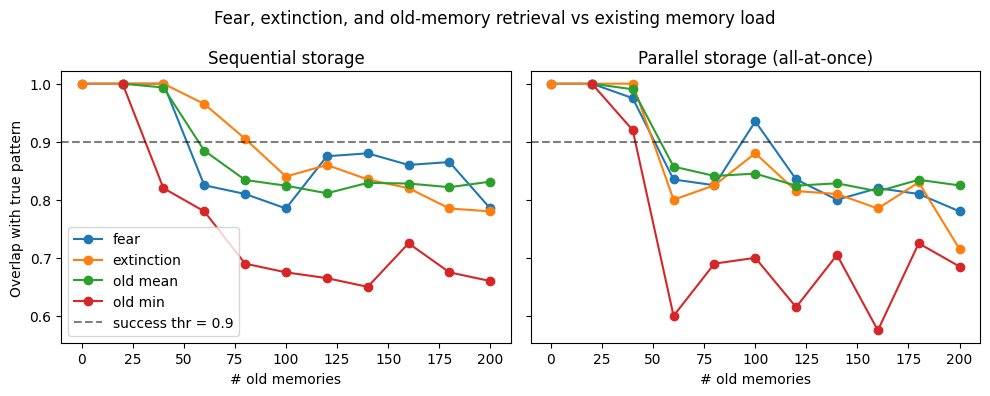

In [5]:
# Plot overlaps as a function of number of old memories

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(results_seq["n_old"], results_seq["fear"], "o-", label="fear")
axes[0].plot(results_seq["n_old"], results_seq["ext"], "o-", label="extinction")
axes[0].plot(results_seq["n_old"], results_seq["old_mean"], "o-", label="old mean")
axes[0].plot(results_seq["n_old"], results_seq["old_min"], "o-", label="old min")
axes[0].axhline(0.9, color="k", linestyle="--", alpha=0.5, label="success thr = 0.9")
axes[0].set_title("Sequential storage")
axes[0].set_xlabel("# old memories")
axes[0].set_ylabel("Overlap with true pattern")
axes[0].legend(loc="best")

axes[1].plot(results_par["n_old"], results_par["fear"], "o-", label="fear")
axes[1].plot(results_par["n_old"], results_par["ext"], "o-", label="extinction")
axes[1].plot(results_par["n_old"], results_par["old_mean"], "o-", label="old mean")
axes[1].plot(results_par["n_old"], results_par["old_min"], "o-", label="old min")
axes[1].axhline(0.9, color="k", linestyle="--", alpha=0.5, label="success thr = 0.9")
axes[1].set_title("Parallel storage (all-at-once)")
axes[1].set_xlabel("# old memories")

plt.suptitle("Fear, extinction, and old-memory retrieval vs existing memory load")
plt.tight_layout()
plt.show()

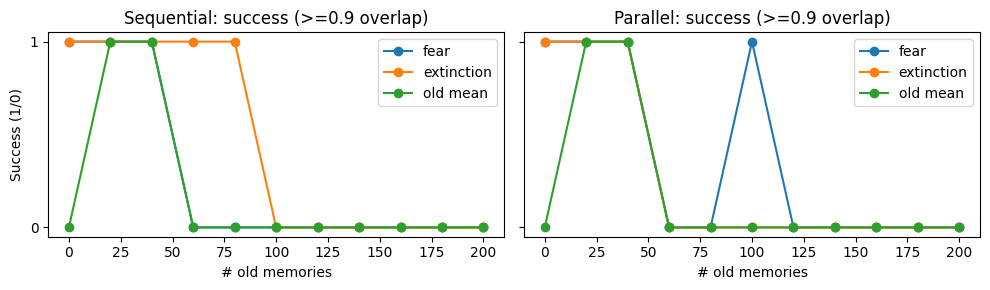

In [6]:
# Optional: convert overlaps into retrieval success (overlap >= 0.9)

seq_fear_succ = np.array(results_seq["fear"]) >= 0.9
seq_ext_succ = np.array(results_seq["ext"]) >= 0.9
seq_old_mean_succ = np.array(results_seq["old_mean"]) >= 0.9

par_fear_succ = np.array(results_par["fear"]) >= 0.9
par_ext_succ = np.array(results_par["ext"]) >= 0.9
par_old_mean_succ = np.array(results_par["old_mean"]) >= 0.9

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

axes[0].plot(results_seq["n_old"], seq_fear_succ.astype(float), "o-", label="fear")
axes[0].plot(results_seq["n_old"], seq_ext_succ.astype(float), "o-", label="extinction")
axes[0].plot(results_seq["n_old"], seq_old_mean_succ.astype(float), "o-", label="old mean")
axes[0].set_title("Sequential: success (>=0.9 overlap)")
axes[0].set_xlabel("# old memories")
axes[0].set_ylabel("Success (1/0)")
axes[0].set_yticks([0, 1])
axes[0].legend(loc="best")

axes[1].plot(results_par["n_old"], par_fear_succ.astype(float), "o-", label="fear")
axes[1].plot(results_par["n_old"], par_ext_succ.astype(float), "o-", label="extinction")
axes[1].plot(results_par["n_old"], par_old_mean_succ.astype(float), "o-", label="old mean")
axes[1].set_title("Parallel: success (>=0.9 overlap)")
axes[1].set_xlabel("# old memories")
axes[1].set_yticks([0, 1])
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

## Notes for interpretation

- The left/right panels compare **sequential vs parallel storage** (Dan's question about how memories are added).
- Lines show overlaps for **fear**, **extinction**, and **old memories** as you increase the number of pre-existing memories.
- Look for the point where curves drop below the 0.9 line: that’s the empirical **capacity/crash** for these parameters \(N_\text{neurons}, p\).
- You can change `n_neurons`, `sparsity`, and the `n_old_list` range at the top to explore other regimes.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, retrieval_success

rng = np.random.default_rng(0)

n_neurons = 2000
sparsity = 0.1
n_old = 50

# 1) initialize network with many old memories
net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
old_patterns = [generate_sparse_pattern(n_neurons, sparsity, rng=rng) for _ in range(n_old)]
for p in old_patterns:
    net.store_pattern_sequential(p)

# 2) learn fear memory
fear_pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
net.store_pattern_sequential(fear_pattern)

# 3) learn extinction memory
ext_pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
net.store_pattern_sequential(ext_pattern)

def retrieve_overlap(net, pattern):
    final_state, traj, energies = net.run(
        initial_state=pattern,
        external_input=None,
        beta=1.0,
        theta=0.0,
        max_steps=50,
        asynchronous=False,
    )
    return pattern_overlap(final_state, pattern)

fear_ov = retrieve_overlap(net, fear_pattern)
ext_ov = retrieve_overlap(net, ext_pattern)
old_ovs = [retrieve_overlap(net, p) for p in old_patterns]

print("Fear overlap:", fear_ov)
print("Extinction overlap:", ext_ov)
print("Old memories: mean, min:", np.mean(old_ovs), np.min(old_ovs))

Fear overlap: 1.0
Extinction overlap: 0.88
Old memories: mean, min: 0.9406 0.73
